# Pre trained

In [1]:
#from transformers import DistilBertTokenizer
#
#tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased', do_lower_case=True)
#cls_token_id = tokenizer.cls_token_id  # or tokenizer.convert_tokens_to_ids("[CLS]")
#mask_token_id = tokenizer.mask_token_id  # or tokenizer.convert_tokens_to_ids("[MASK]")
#pad_token_id = tokenizer.pad_token_id  # or tokenizer.convert_tokens_to_ids("[MASK]")
#vocab_size=tokenizer.vocab_size

In [2]:
#tokenizer.encode("you are bruh", add_special_tokens=True)

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import numpy as np

In [4]:
#train_set_large = train_set.sample(frac=1).reset_index(drop=True)
large_set = pd.read_csv("995,000_rows.csv").sample(frac=0.0002).reset_index(drop=True)
large_set = large_set[["content", "type", "title"]].dropna()

/var/folders/89/bk15wb4x33g0_6ndpf2c8rqh0000gn/T/ipykernel_58893/370336790.py:2: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  large_set = pd.read_csv("995,000_rows.csv").sample(frac=0.0002).reset_index(drop=True)


In [5]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.normalizers import NFD, StripAccents, Lowercase

tokenizer = Tokenizer(BPE())
tokenizer.normalizer = NFD()
tokenizer.pre_tokenizer = Whitespace()

vocab_size=40000
trainer = BpeTrainer(vocab_size=vocab_size, special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"])

tokenizer.train_from_iterator(large_set["content"], trainer=trainer)

tokenizer.save("bpe_tokenizer.json")

cls_token_id = tokenizer.token_to_id("[CLS]")
mask_token_id = tokenizer.token_to_id("[MASK]")
pad_token_id = tokenizer.token_to_id("[PAD]")

In [6]:
label_map = {
    "fake": "fake",
    "satire": None,
    "bias": None,
    "conspiracy": "fake",
    "state": None,
    "junksci": "fake",
    "hate": None,
    "clickbait": None,
    "unreliable": None,
    "political": "reliable",
    "reliable": "reliable",
    "unknown": None,
}

In [7]:
large_set["new_labels"] = [label_map.get(n, None) for n in large_set["type"]]
label_counts = large_set['new_labels'].value_counts()
print(label_counts)
min_count = label_counts.min()
large_set = large_set.groupby('new_labels').apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)

#large_set["content_tokens"] = fn.tokenize(large_set["content"])

nfake = sum(large_set["new_labels"] == "fake")
nreliable = sum(large_set["new_labels"] == "reliable")

print(nfake / (nfake + nreliable))

new_labels
reliable    74
fake        46
Name: count, dtype: int64
0.5


/var/folders/89/bk15wb4x33g0_6ndpf2c8rqh0000gn/T/ipykernel_58893/3859408910.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  large_set = large_set.groupby('new_labels').apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)


In [8]:
import random

def mask_random_elements(sequence, mask_probability=0.15):
    masked_sequence = sequence[:]
    for idx in range(len(sequence)):
        if random.random() < mask_probability and sequence[idx] != pad_token_id:
            masked_sequence[idx] = mask_token_id
    return masked_sequence

max_seq_len = 300

def tokenize(text):
    tokens = tokenizer.encode(text)
    tokens = [cls_token_id] + tokens.ids
    tokens = tokens[:max_seq_len]
    while len(tokens) < max_seq_len:
        tokens.append(pad_token_id)
    return tokens

text_ids = [tokenize(text) for text in large_set["content"]]
text_ids_masked = [mask_random_elements(text_id) for text_id in text_ids]
att_masks = [[id != pad_token_id for id in ids] for ids in text_ids]

In [9]:
from sklearn.model_selection import train_test_split

labels = [1.0 if n == "fake" else 0 for n in large_set["new_labels"]]

train_x, test_val_x, train_y, test_val_y = train_test_split(text_ids, labels, test_size=0.2)
train_m, test_val_m = train_test_split(att_masks, test_size=0.2)
train_mlm, test_val_mlm = train_test_split(text_ids_masked, test_size=0.2)

test_x, val_x, test_y, val_y = train_test_split(test_val_x, test_val_y, test_size=0.5)
test_m, val_m = train_test_split(test_val_m, test_size=0.5)

In [10]:
from torch.nested import nested_tensor

#train_x = [torch.tensor(x) for x in train_x]
#test_x = [torch.tensor(x) for x in test_x]
train_x = torch.tensor(train_x)
test_x = torch.tensor(test_x)
train_mlm = torch.tensor(train_mlm)
val_x = torch.tensor(val_x)

train_y = torch.tensor(train_y)
test_y = torch.tensor(test_y)
val_y = torch.tensor(val_y)

train_m = torch.tensor(train_m)
test_m = torch.tensor(test_m)
val_m = torch.tensor(val_m)

In [11]:
#train_x = torch.tensor([n for n in train_set_large["tokens"]])

In [12]:
#train_y = torch.tensor([int(n == "fake") for n in train_set_large["new_labels"]])

In [13]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

batch_size = 32

train_data = TensorDataset(train_x, train_m, train_y, train_mlm)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(val_x, val_m, val_y)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=batch_size)

In [14]:
from transformers import DistilBertModel, DistilBertConfig
from torch.optim import Adam, AdamW
from torch import nn, functional as F
import math

num_labels = 2
device = torch.device("mps")

class BertClassifier(nn.Module):
    def __init__(self):
        super(BertClassifier, self).__init__()
        #self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased', output_attentions=False, output_hidden_states=False)
        #self.out = nn.Linear(self.bert.config.dim, 1)
        
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=512, nhead=4)
        self.use_nested_tensor=True
        self.encoder_layer.self_attn.batch_first=True
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=6, norm = nn.LayerNorm(512))

        self.embeddings = nn.Embedding(num_embeddings=vocab_size, embedding_dim=512, padding_idx=0)
        self.positional_encoding = torch.zeros([max_seq_len, 512])#, requires_grad=True)
        position = torch.arange(0, max_seq_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, 512, 2).float() * -(math.log(10000.0) / 512))
        self.positional_encoding[:, 0::2] = torch.sin(position * div_term)
        self.positional_encoding[:, 1::2] = torch.cos(position * div_term)

        self.preclassifier = nn.Linear(512, 512)
        self.classifier = nn.Linear(512, 1)
        self.distribution = nn.Linear(512, vocab_size, bias=False)
        self.distribution.weight = self.embeddings.weight

    def hidden(self, seq, **kwargs):
        x = self.embeddings(seq)
        expanded_positional_encoding = self.positional_encoding.unsqueeze(0)  # Shape: (1, sequence_length, embedding_size)
        expanded_positional_encoding = expanded_positional_encoding.expand(x.shape[0], -1, -1).to(device)  # Shape: (batch_size, sequence_length, embedding_size)
        x += expanded_positional_encoding[:x.size(0), :x.size(1), :x.size(2)]
        #print(x)
        return self.transformer_encoder(x, **kwargs)

    def classify(self, seq, **kwargs):
        outputs = self.classifier(self.preclassifier(hidden[:,0]).relu())
        return output
    
    def classify_loss(self, hidden, mb_y):
        outputs = self.classifier(self.preclassifier(hidden[:,0]).relu())
        loss_cls = torch.nn.functional.mse_loss(outputs.view(-1), mb_y)
        return loss_cls

    def mlm_loss(self, hidden, mb_x):
        outputs = self.distribution(hidden)[:,1:,:]
        loss_mlm = torch.nn.functional.cross_entropy(outputs.reshape(-1, vocab_size), mb_x[:,1:].reshape(-1))
        return loss_mlm
    
model = BertClassifier()

model = model.to(device)
model.train()
model.compile()

In [15]:
learning_rate = 1e-4
adam_epsilon = 1e-8

optimizer = AdamW(model.named_parameters(), lr=learning_rate, eps=adam_epsilon)

In [16]:
from transformers import get_linear_schedule_with_warmup

num_epochs = 10
total_steps = len(train_dataloader) * num_epochs

scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

In [17]:
import time

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs


In [18]:
train_losses = []
val_losses = []
num_mb_train = len(train_dataloader)
num_mb_val = len(val_dataloader)
missed_batches = 0

if num_mb_val == 0:
    num_mb_val = 1

for n in range(num_epochs):
    train_loss = 0
    val_loss = 0
    start_time = time.time()
    
    for k, (mb_x, mb_m, mb_y, mb_mlm) in enumerate(train_dataloader):
        optimizer.zero_grad()
        model.train()

        if mb_x.shape[0] != 32:
            missed_batches += 1
            continue
        
        mb_x = mb_x.to(device)
        mb_m = mb_m.to(device)
        mb_y = mb_y.to(device)
        mb_mlm = mb_mlm.to(device)

        hidden = model.hidden(mb_mlm)#, src_key_padding_mask=mb_m.transpose(0,1))
        loss_cls = model.classify_loss(hidden, mb_y)
        loss_mlm = model.mlm_loss(hidden, mb_x)

        loss = loss_cls + loss_mlm
        loss.backward()
        
        optimizer.step()
        scheduler.step()
        
        train_loss = loss.data

        # Track time for every batch
        elapsed_time = time.time() - start_time
        batches_done = k + 1
        batches_total = len(train_dataloader)
        
        # Estimate time remaining (ETA)
        remaining_batches = batches_total - batches_done
        eta_seconds = (elapsed_time / batches_done) * remaining_batches
        eta_str = str(time.strftime("%H:%M:%S", time.gmtime(eta_seconds)))

        train_losses.append(train_loss.cpu().detach().item())

        # Print current status and ETA
        print(f"Loss: {float(np.mean(train_losses)):.2f} - ETA of epoch: {eta_str}", end='\r')
    
    print (f"\n missed {missed_batches} batches")
    
    with torch.no_grad():
        model.eval()
        
        for k, (mb_x, mb_m, mb_y) in enumerate(val_dataloader):
            mb_x = mb_x.to(device)
            mb_m = mb_m.to(device)
            mb_y = mb_y.to(device)

            if mb_x.shape[0] != 32:
                missed_batches += 1
                continue

            hidden = model.hidden(mb_x)#, src_key_padding_mask=mb_m.transpose(0,1))
            loss_cls = model.classify_loss(hidden, mb_y)
        
            val_loss += loss_cls.data.cpu().detach().item() / num_mb_val
            
        print ("CLS validation loss after itaration %i: %f" % (n+1, val_loss))
        val_losses.append(val_loss) 
    
    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    print(f'Time: {epoch_mins}m {epoch_secs}s')

Loss: 112.45 - ETA of epoch: 00:00:02
 missed 1 batches
CLS validation loss after itaration 1: 0.000000
Time: 0m 4s
Loss: 97.48 - ETA of epoch: 00:00:014
 missed 3 batches
CLS validation loss after itaration 2: 0.000000
Time: 0m 4s
Loss: 90.19 - ETA of epoch: 00:00:02
 missed 5 batches
CLS validation loss after itaration 3: 0.000000
Time: 0m 6s
Loss: 85.43 - ETA of epoch: 00:00:03
 missed 7 batches
CLS validation loss after itaration 4: 0.000000
Time: 0m 7s
Loss: 81.91 - ETA of epoch: 00:00:02
 missed 9 batches
CLS validation loss after itaration 5: 0.000000
Time: 0m 5s
Loss: 79.11 - ETA of epoch: 00:00:01
 missed 11 batches
CLS validation loss after itaration 6: 0.000000
Time: 0m 5s
Loss: 76.77 - ETA of epoch: 00:00:03
 missed 13 batches
CLS validation loss after itaration 7: 0.000000
Time: 0m 7s
Loss: 74.78 - ETA of epoch: 00:00:02
 missed 15 batches
CLS validation loss after itaration 8: 0.000000
Time: 0m 5s
Loss: 73.12 - ETA of epoch: 00:00:03
 missed 17 batches
CLS validation loss

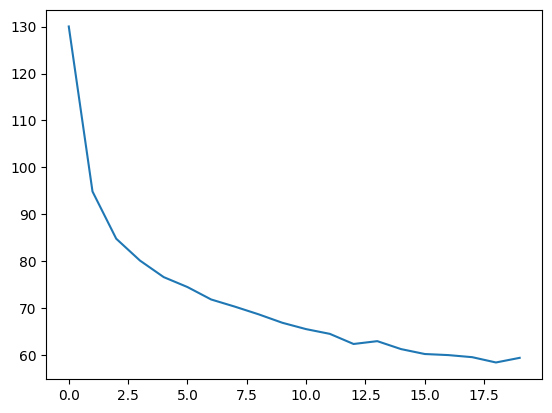

In [19]:
from matplotlib import pyplot as plt
%matplotlib inline

plt.figure()
plt.plot(train_losses)

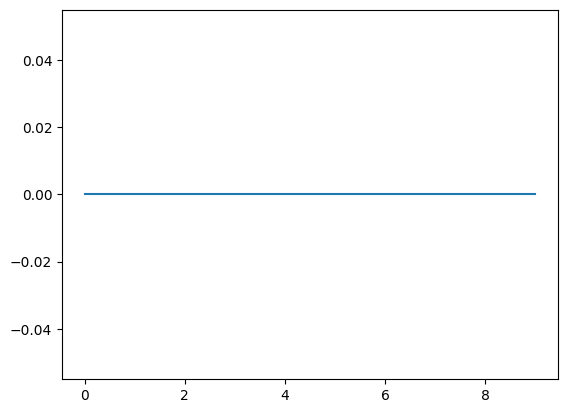

In [20]:
plt.figure()
plt.plot(val_losses)

In [21]:
batch_size = 32

test_data = TensorDataset(test_x, test_m)
test_sampler = SequentialSampler(test_data)
test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=batch_size)

nbatches = int(len(test_x) / 32)

outputs = []
with torch.no_grad():
    model.eval()
    #for k in range(nbatches):
    for k, (mb_x, mb_m) in enumerate(test_dataloader):
        #mb_x = nested_tensor(test_x[k*32:(k+1)*32])#, device=device)
        mb_x = mb_x.to(device)
        mb_m = mb_m.to(device)
        hidden = model.hidden(mb_x)
        output = model.classifier(model.preclassifier(hidden[:,0]).relu())
        outputs.append(output)

outputs = torch.cat(outputs)

In [22]:
hidden_states = []
with torch.no_grad():
    model.eval()
    for k, (mb_x, mb_m) in enumerate(test_dataloader):
        #mb_x = torch.tensor(mb_x).unsqueeze(0).to(device)
        mb_x = torch.tensor(mb_x).to(device)
        mb_m = mb_m.to(device)
        hidden = model.hidden(mb_x)
        output = hidden[:,0]
        #print(mb_x.shape)
        #if any(all(i == False for i in mb_m[n,:]) for n in range(mb_m.size(0))):
        #    print("FUCK")
        hidden_states.append(output)

hidden_states = torch.cat(hidden_states)
hidden_states

/var/folders/89/bk15wb4x33g0_6ndpf2c8rqh0000gn/T/ipykernel_58893/597254197.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mb_x = torch.tensor(mb_x).to(device)


tensor([[ 0.6350,  1.8944,  0.2541,  ..., -0.4256,  1.2036,  0.3511],
        [ 0.6169,  1.8812,  0.2672,  ..., -0.4145,  1.2070,  0.3390],
        [ 0.6405,  1.8767,  0.2646,  ..., -0.4165,  1.1934,  0.3541],
        ...,
        [ 0.6445,  1.8852,  0.2542,  ..., -0.4352,  1.2085,  0.3472],
        [ 0.6309,  1.8758,  0.2646,  ..., -0.4164,  1.2011,  0.3498],
        [ 0.6324,  1.8845,  0.2635,  ..., -0.4117,  1.1992,  0.3631]],
       device='mps:0')

In [23]:
hidden_states.shape

torch.Size([9, 512])

In [24]:
model.embeddings(torch.tensor(cls_token_id).to(device)).view(1,-1)

tensor([[ 0.9824, -0.0340, -1.1840, -0.3669,  0.3265,  2.2024,  1.1017, -0.1983,
         -1.0790,  2.2851,  0.4335, -0.6271,  0.3463, -0.3149,  2.1215, -0.3527,
          1.5108, -0.2729,  0.4787,  0.4226,  0.6014,  0.4537, -0.6906, -0.3455,
         -0.5572,  0.1782,  1.8584, -0.9529, -0.0622,  0.8293, -0.0504, -0.1151,
         -1.3138, -0.8592,  0.4218,  0.8049,  0.9417, -1.8595,  0.8929, -2.3076,
          0.6931,  1.3153, -0.9293, -0.4164, -0.0940,  2.3034,  1.8419, -2.4100,
         -0.1143,  0.6457,  1.2751,  0.7749,  1.0678,  1.9143, -0.1299,  0.3114,
          0.2068, -0.2685, -0.6209, -0.1200, -0.5840, -2.4370,  1.0922,  1.9876,
          1.6621, -0.9507, -1.0410,  1.3916,  0.3685, -0.5639,  0.5309,  1.3793,
          1.5033,  0.6506, -1.8703, -1.8443,  1.5983, -0.5891, -1.6315, -0.3387,
         -0.1492,  0.2407, -0.2377, -0.9151, -0.6499, -1.2035,  1.8085,  0.8508,
          2.0105, -1.6573, -0.0912,  0.4750,  1.4883, -0.4699, -1.3052,  0.3795,
          1.3390,  0.1707, -

In [25]:
predicted_values = torch.round(outputs)
predicted_values = predicted_values.cpu().view(-1).numpy()
true_values = test_y.numpy()

In [26]:
import numpy as np

In [27]:
test_accuracy = np.sum(predicted_values == true_values) / len(true_values)
print ("Test Accuracy:", test_accuracy)

Test Accuracy: 0.3333333333333333


In [28]:
label_values = ["reliabel", "fake"]

In [29]:
from sklearn.metrics import classification_report

print(classification_report(true_values, predicted_values, target_names=[str(l) for l in label_values]))

              precision    recall  f1-score   support

    reliabel       0.33      1.00      0.50         3
        fake       0.00      0.00      0.00         6

    accuracy                           0.33         9
   macro avg       0.17      0.50      0.25         9
weighted avg       0.11      0.33      0.17         9



/Users/akselrasmussen/uni/ds/fake_news/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akselrasmussen/uni/ds/fake_news/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akselrasmussen/uni/ds/fake_news/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [30]:
import itertools

# plot confusion matrix
# code borrowed from scikit-learn.org
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Normalized confusion matrix
[[1. 0.]
 [1. 0.]]


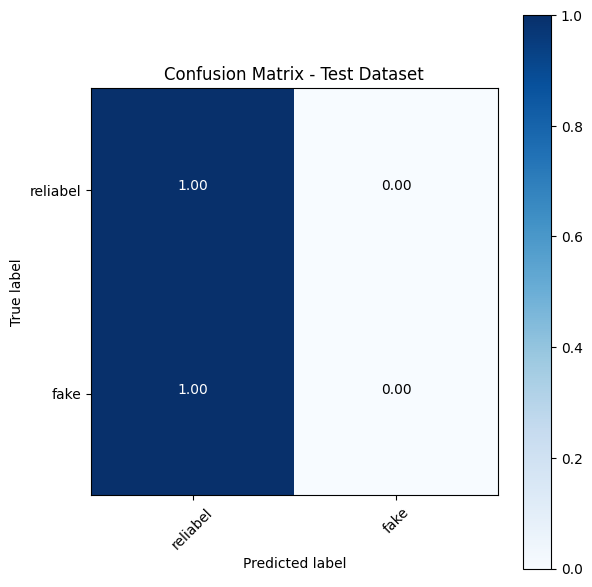

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

cm_test = confusion_matrix(true_values, predicted_values)

np.set_printoptions(precision=2)

#plt.figure(figsize=(6,6))
#plot_confusion_matrix(cm_test, classes=label_values, title='Confusion Matrix - Test Dataset')
plt.figure(figsize=(6,6))
plot_confusion_matrix(cm_test, classes=label_values, title='Confusion Matrix - Test Dataset', normalize=True)